In [ ]:
import sys
from pathlib import Path
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt

workspace_root = Path.cwd()
while not (workspace_root / "pyproject.toml").exists() and workspace_root != workspace_root.parent:
    workspace_root = workspace_root.parent

if not (workspace_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the QCMet workspace root")

sys.path.insert(0, str(workspace_root))

from qcmet.benchmarks.circuit_execution_quality_metrics.linear_xeb import LinearXEB
from qcmet import AerSimulator

In [ ]:
n_qubits = 6
depth = 20
num_circuits = 500
seed = 42

In [12]:
experiment = LinearXEB(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
    seed=seed,
)

experiment.generate_circuits()
experiment.run(
    device=AerSimulator(seed_simulator=seed),
    num_shots=1024
)

experiment.analyze()['mean_fidelity']

0.9909365706159237

In [ ]:
# print example circuit
# experiment.circuits[0].draw()

┌────────────┐   ┌────────────┐      ┌────────────┐   ┌────────────┐   »
   q_0: ┤ Haar SU(2) ├─■─┤ Haar SU(2) ├────■─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├───»
        ├────────────┤ │ ├────────────┤    │ ├────────────┤ │ ├────────────┤   »
   q_1: ┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■─»
        ├────────────┤   ├────────────┤ │  │ ├────────────┤   ├────────────┤ │ »
   q_2: ┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■─»
        ├────────────┤ │ ├────────────┤    │ ├────────────┤ │ ├────────────┤   »
   q_3: ┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■─»
        ├────────────┤   ├────────────┤ │  │ ├────────────┤   ├────────────┤ │ »
   q_4: ┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■─»
        ├────────────┤ │ ├────────────┤    │ ├────────────┤ │ ├────────────┤   »
   q_5: ┤ Haar SU(2) ├─■─┤ Haar SU(2) ├────■─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├───»
        └────────────┘   └────────────┘      └────────────┘   └────────────┘   »
meas: 6/═══════════════════════════════════════════════════════════════════════»
                                                                               »
«           ┌────────────┐   ┌────────────┐      ┌────────────┐   »
«   q_0: ─■─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├────■─┤ Haar SU(2) ├─■─»
«         │ ├────────────┤ │ ├────────────┤    │ ├────────────┤ │ »
«   q_1: ─┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─»
«         │ ├────────────┤   ├────────────┤ │  │ ├────────────┤   »
«   q_2: ─┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─»
«         │ ├────────────┤ │ ├────────────┤    │ ├────────────┤ │ »
«   q_3: ─┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─»
«         │ ├────────────┤   ├────────────┤ │  │ ├────────────┤   »
«   q_4: ─┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─»
«         │ ├────────────┤ │ ├────────────┤    │ ├────────────┤ │ »
«   q_5: ─■─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├────■─┤ Haar SU(2) ├─■─»
«           └────────────┘   └────────────┘      └────────────┘   »
«meas: 6/═════════════════════════════════════════════════════════»
«                                                                 »
«        ┌────────────┐      ┌────────────┐   ┌────────────┐       ░ ┌─┐      »
«   q_0: ┤ Haar SU(2) ├────■─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├────■──░─┤M├──────»
«        ├────────────┤    │ ├────────────┤ │ ├────────────┤    │  ░ └╥┘┌─┐   »
«   q_1: ┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼──░──╫─┤M├───»
«        ├────────────┤ │  │ ├────────────┤   ├────────────┤ │  │  ░  ║ └╥┘┌─┐»
«   q_2: ┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼──░──╫──╫─┤M├»
«        ├────────────┤    │ ├────────────┤ │ ├────────────┤    │  ░  ║  ║ └╥┘»
«   q_3: ┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼──░──╫──╫──╫─»
«        ├────────────┤ │  │ ├────────────┤   ├────────────┤ │  │  ░  ║  ║  ║ »
«   q_4: ┤ Haar SU(2) ├─■──┼─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├─■──┼──░──╫──╫──╫─»
«        ├────────────┤    │ ├────────────┤ │ ├────────────┤    │  ░  ║  ║  ║ »
«   q_5: ┤ Haar SU(2) ├────■─┤ Haar SU(2) ├─■─┤ Haar SU(2) ├────■──░──╫──╫──╫─»
«        └────────────┘      └────────────┘   └────────────┘       ░  ║  ║  ║ »
«meas: 6/═════════════════════════════════════════════════════════════╩══╩══╩═»
«                                                                     0  1  2 »
«                 
«   q_0: ─────────
«                 
«   q_1: ─────────
«                 
«   q_2: ─────────
«        ┌─┐      
«   q_3: ┤M├──────
«        └╥┘┌─┐   
«   q_4: ─╫─┤M├───
«         ║ └╥┘┌─┐
«   q_5: ─╫──╫─┤M├
«         ║  ║ └╥┘
«meas: 6/═╩══╩══╩═
«         3  4  5

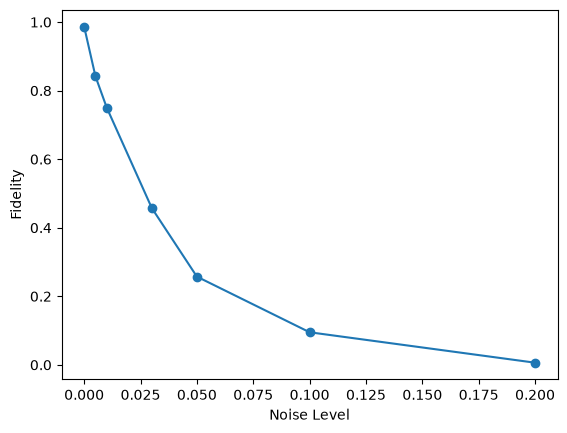

In [ ]:
# Model with noise. As we increase the noise, the fidelity should decrease.
# constant depth of 10, which is enough to scramble effectively such that fidelity ~1 for no noise

n_qubits = 6
depth = 10
num_circuits = 50
seed = 42

noise_levels = [0.0, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2]
fidelities = []

for noise in noise_levels:
    
    noise_model = NoiseModel()
    # one qubit noise
    # error = depolarizing_error(noise, 1)
    # noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3"])

    # two qubit noise
    error2 = depolarizing_error(noise, 2)
    noise_model.add_all_qubit_quantum_error(error2, ["cz", "cx"])

    noisy_simulator = AerSimulator(
        noise_model=noise_model,
        seed_simulator=seed
    )

    experiment = LinearXEB(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
    seed=seed
    )

    experiment.generate_circuits()
    experiment.run(
        device=noisy_simulator,
        num_shots=50
    )
    
    fidelities.append(experiment.analyze()['mean_fidelity'])

plt.plot(noise_levels, fidelities, 'o-')
plt.xlabel('Noise Level')
plt.ylabel('Fidelity')
plt.show()


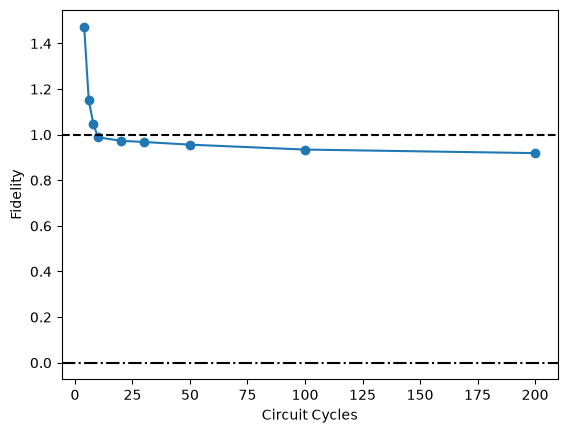

In [ ]:
# fidelity versus circuit depth.
# There should be two phases, a scrambling phase, where the fidelity decreases to ~1 
# due to the randomization of the circuit, and then a decay phase where the fidelity decreases further due to noise accumulation.
n_qubits = 6
num_circuits = 300
seed = 42

depths = [4, 6, 8, 10, 20, 30, 50, 100, 200]
noise = 0.0001
fidelities = []

noise_model = NoiseModel()

# one qubit noise
# error = depolarizing_error(noise, 1)
# noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3"])

# two qubit noise
error2 = depolarizing_error(noise, 2)
noise_model.add_all_qubit_quantum_error(error2, ["cz", "cx"])
for depth in depths:
    print()

    noisy_simulator = AerSimulator(
        noise_model=noise_model,
        seed_simulator=seed
    )

    experiment = LinearXEB(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
    seed=seed
    )

    experiment.generate_circuits()
    experiment.run(
        device=noisy_simulator,
        num_shots=1024
    )
    
    fidelities.append(experiment.analyze()['mean_fidelity'])

plt.plot(depths, fidelities, 'o-')
plt.axhline(y = 1, color = 'k', linestyle = '--')
plt.axhline(y = 0, color = 'k', linestyle = '-.')
plt.xlabel('Circuit Cycles')
plt.ylabel('Fidelity')
plt.show()

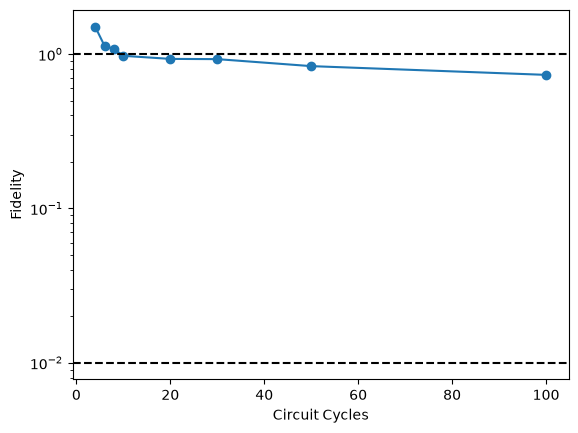

In [28]:
plt.semilogy(depths, fidelities, 'o-')
plt.axhline(y = 1, color = 'k', linestyle = '--')
plt.axhline(y = 0.01, color = 'k', linestyle = '--')
plt.xlabel('Circuit Cycles')
plt.ylabel('Fidelity')
plt.show()